## Imports, configuration

In [1]:
import os, re, math, random, json, pickle, time
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

random.seed(0); np.random.seed(0); torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

WORK_ROOT   = Path("lpnr_plate")
LABELS_CSV  = WORK_ROOT / "labels.csv"
OUT_DIR     = Path("recognition_results"); OUT_DIR.mkdir(exist_ok=True)
N_FOLDS     = 4
BATCH_SIZE  = 128

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
if DEVICE == "cuda":
    print("       ", torch.cuda.get_device_name(0))
assert LABELS_CSV.exists(), (
    f"Cache not found at {LABELS_CSV}. Run the dataset-prep notebook first.")
print(f"using cache: {LABELS_CSV}")

device: cuda
        NVIDIA GeForce RTX 2060
using cache: lpnr_plate/labels.csv


## Character vocabulary

In [2]:
PROVINCES = ['皖','沪','津','渝','冀','晋','蒙','辽','吉','黑','苏','浙','京',
             '闽','赣','鲁','豫','鄂','湘','粤','桂','琼','川','贵','云','藏',
             '陕','甘','青','宁','新','警','学','O']
ALPHABETS = ['A','B','C','D','E','F','G','H','J','K','L','M','N',
             'P','Q','R','S','T','U','V','W','X','Y','Z','O']
ADS = ['A','B','C','D','E','F','G','H','J','K','L','M','N',
       'P','Q','R','S','T','U','V','W','X','Y','Z',
       '0','1','2','3','4','5','6','7','8','9','O']

REAL_PROVINCES = [p for p in PROVINCES if p != 'O']     # 33
REAL_LETTERS   = [a for a in ALPHABETS if a != 'O']     # 24
REAL_DIGITS    = [d for d in ADS if d.isdigit()]        # 10

VOCAB    = ['<blank>'] + REAL_PROVINCES + REAL_LETTERS + REAL_DIGITS
CHAR2IDX = {c: i for i, c in enumerate(VOCAB)}
IDX2CHAR = {i: c for c, i in CHAR2IDX.items()}
N_CLASSES = len(VOCAB); BLANK_IDX = 0

HEAD_CLASSES = [
    REAL_PROVINCES,
    REAL_LETTERS,
    REAL_LETTERS + REAL_DIGITS,
    REAL_LETTERS + REAL_DIGITS,
    REAL_LETTERS + REAL_DIGITS,
    REAL_LETTERS + REAL_DIGITS,
    REAL_LETTERS + REAL_DIGITS,
]
HEAD_CHAR2IDX = [{c: i for i, c in enumerate(h)} for h in HEAD_CLASSES]
HEAD_IDX2CHAR = [{i: c for c, i in m.items()} for m in HEAD_CHAR2IDX]
HEAD_SIZES    = [len(h) for h in HEAD_CLASSES]

def encode_ctc(plate):
    return [CHAR2IDX[c] for c in plate]
def encode_7head(plate):
    return [HEAD_CHAR2IDX[i][plate[i]] for i in range(7)]

print(f"CTC vocabulary: {N_CLASSES} classes (incl. blank)")
print(f"7-head sizes:   {HEAD_SIZES}")

CTC vocabulary: 68 classes (incl. blank)
7-head sizes:   [33, 24, 34, 34, 34, 34, 34]


## 3. Load the cache and split

In [ ]:
DATASET_ROOT = Path("Dataset")         
CROPS_DIR    = WORK_ROOT / "crops"
CROP_OUT_H   = 48                      
CROP_OUT_W   = 168

SAMPLE_TARGET    = 80000                 
TEST_FRACTION    = 0.15
MIN_PER_SUBSET   = 100                  # floor so rare subsets are usable
SEED             = 0

def _need_rebuild():
    if not LABELS_CSV.exists(): return True
    # If labels.csv exists but the first few crops don't, treat as stale
    try:
        head = pd.read_csv(LABELS_CSV, nrows=5)
        if not all(Path(p).exists() and Path(p).stat().st_size > 0 for p in head["path"]):
            return True
    except Exception:
        return True
    return False

if _need_rebuild():
    print("Cache missing or stale — rebuilding from raw CCPD...")
    assert DATASET_ROOT.exists(), f"CCPD root not found at {DATASET_ROOT.resolve()}"

    # CCPD's official vertex order is right-bottom, left-bottom, left-top, right-top.
    # We reorder to TL,TR,BR,BL for cv2.getPerspectiveTransform.
    PROVINCES_PARSE = ['皖','沪','津','渝','冀','晋','蒙','辽','吉','黑','苏','浙','京',
                       '闽','赣','鲁','豫','鄂','湘','粤','桂','琼','川','贵','云','藏',
                       '陕','甘','青','宁','新','警','学','O']
    ALPHABETS_PARSE = ['A','B','C','D','E','F','G','H','J','K','L','M','N',
                       'P','Q','R','S','T','U','V','W','X','Y','Z','O']
    ADS_PARSE = ['A','B','C','D','E','F','G','H','J','K','L','M','N',
                 'P','Q','R','S','T','U','V','W','X','Y','Z',
                 '0','1','2','3','4','5','6','7','8','9','O']

    def parse_ccpd(path):
        f = Path(path).stem.split('-')
        if len(f) != 7: return None
        try:
            verts = [tuple(map(int, p.split('&'))) for p in f[3].split('_')]
            if len(verts) != 4: return None
            idxs = list(map(int, f[4].split('_')))
            plate = (PROVINCES_PARSE[idxs[0]] + ALPHABETS_PARSE[idxs[1]] +
                     ''.join(ADS_PARSE[i] for i in idxs[2:]))
        except (ValueError, IndexError):
            return None
        return {"vertices": verts, "plate": plate}

    def discover_subset(p):
        try:
            return p.relative_to(DATASET_ROOT).parts[0]
        except ValueError:
            return "unknown"

    def order_corners(pts):
        pts = np.asarray(pts, dtype=np.float32)
        s = pts.sum(axis=1); d = np.diff(pts, axis=1).ravel()
        # TL has smallest sum; BR largest sum; TR smallest diff; BL largest diff
        return np.stack([pts[np.argmin(s)], pts[np.argmin(d)],
                         pts[np.argmax(s)], pts[np.argmax(d)]])

    def rectify(img_bgr, vertices, out_w=CROP_OUT_W, out_h=CROP_OUT_H):
        src = order_corners(vertices).astype(np.float32)
        dst = np.array([[0,0],[out_w-1,0],[out_w-1,out_h-1],[0,out_h-1]], dtype=np.float32)
        M = cv2.getPerspectiveTransform(src, dst)
        return cv2.warpPerspective(img_bgr, M, (out_w, out_h))

    # scan CCPD and group images by subset
    by_subset = {}
    for p in DATASET_ROOT.rglob("*.jpg"):
        by_subset.setdefault(discover_subset(p), []).append(p)
    print(f"Found {sum(len(v) for v in by_subset.values()):,} images across "
          f"{len(by_subset)} subsets: {[(k, len(v)) for k, v in by_subset.items()]}")

    # stratified proportional sample 
    rng = random.Random(SEED)
    for v in by_subset.values(): rng.shuffle(v)
    total = sum(len(v) for v in by_subset.values())
    alloc = {k: min(MIN_PER_SUBSET, len(v)) for k, v in by_subset.items()}
    used = sum(alloc.values()); remaining = SAMPLE_TARGET - used
    if remaining > 0:
        leftover = {k: max(0, len(v) - alloc[k]) for k, v in by_subset.items()}
        lt = sum(leftover.values())
        if lt > 0:
            for k in by_subset:
                add = int(round(remaining * leftover[k] / lt))
                alloc[k] = min(len(by_subset[k]), alloc[k] + add)
    sampled = {k: by_subset[k][:alloc[k]] for k in by_subset}
    print(f"Sampled per subset: {[(k, len(v)) for k, v in sampled.items()]}")

    # rectify each plate and write the crop
    CROPS_DIR.mkdir(parents=True, exist_ok=True)
    rows = []
    failed = 0; t0 = time.time()
    for subset, plist in sampled.items():
        for p in plist:
            rec = parse_ccpd(p)
            if rec is None: failed += 1; continue
            img = cv2.imread(str(p))
            if img is None: failed += 1; continue
            try:
                crop = rectify(img, rec["vertices"])
            except Exception:
                failed += 1; continue
            out_path = CROPS_DIR / f"{p.stem}.jpg"
            cv2.imwrite(str(out_path), crop)
            rows.append({"path": str(out_path), "plate": rec["plate"],
                         "subset": subset, "src": str(p)})
    print(f"Rectified {len(rows):,} crops in {time.time()-t0:.0f}s ({failed} failed)")

    # assign pool/test split, stratified by subset
    cache_df = pd.DataFrame(rows)
    rng2 = random.Random(SEED + 1)
    splits = []
    for subset, group in cache_df.groupby("subset"):
        idxs = list(group.index); rng2.shuffle(idxs)
        n_test = max(1, int(round(TEST_FRACTION * len(idxs))))
        test_set = set(idxs[:n_test])
        for i in group.index:
            splits.append("test" if i in test_set else "pool")
    cache_df["split"] = splits
    cache_df.to_csv(LABELS_CSV, index=False)
    print(f"Wrote {LABELS_CSV} ({len(cache_df)} rows)")


df = pd.read_csv(LABELS_CSV)
print(f"\nTotal cached crops: {len(df):,}\n")
print("By split:")
print(df.groupby(["split","subset"]).size().unstack(fill_value=0))

pool_df = df[df["split"] == "pool"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)
print(f"\npool: {len(pool_df)}  | test: {len(test_df)}")

Cache missing or stale — rebuilding from raw CCPD...
Found 355,013 images across 9 subsets: [('ccpd_fn', 20967), ('ccpd_challenge', 50003), ('ccpd_weather', 9999), ('ccpd_blur', 20611), ('ccpd_np', 3036), ('ccpd_db', 10132), ('ccpd_rotate', 10053), ('ccpd_base', 199996), ('ccpd_tilt', 30216)]
Sampled per subset: [('ccpd_fn', 4761), ('ccpd_challenge', 11247), ('ccpd_weather', 2311), ('ccpd_blur', 4682), ('ccpd_np', 756), ('ccpd_db', 2341), ('ccpd_rotate', 2323), ('ccpd_base', 44752), ('ccpd_tilt', 6827)]
Rectified 79,244 crops in 174s (756 failed)
Wrote lpnr_plate/labels.csv (79244 rows)

Total cached crops: 79,244

By split:
subset  ccpd_base  ccpd_blur  ccpd_challenge  ccpd_db  ccpd_fn  ccpd_rotate  \
split                                                                         
pool        38092       3897            9592     2004     4036         1958   
test         6660        785            1655      337      725          365   

subset  ccpd_tilt  ccpd_weather  
split           

## PyTorch dataset (shared by both PyTorch models)

In [5]:
class PlateCropDataset(Dataset):
    def __init__(self, df, crop_h, crop_w, augment=False):
        self.df = df.reset_index(drop=True)
        self.crop_h, self.crop_w = crop_h, crop_w
        self.augment = augment
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = cv2.imread(r["path"])
        if img is None:
            img = np.zeros((self.crop_h, self.crop_w, 3), dtype=np.uint8)
        if img.shape[:2] != (self.crop_h, self.crop_w):
            img = cv2.resize(img, (self.crop_w, self.crop_h))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.augment:
            if random.random() < 0.5:
                img = np.clip(img.astype(np.float32) * random.uniform(0.85, 1.15), 0, 255).astype(np.uint8)
            if random.random() < 0.5:
                tx, ty = random.randint(-2, 2), random.randint(-1, 1)
                M = np.float32([[1,0,tx],[0,1,ty]])
                img = cv2.warpAffine(img, M, (self.crop_w, self.crop_h), borderValue=(127,127,127))
        x = (img.astype(np.float32) / 255.0 - 0.5) / 0.5
        x = torch.from_numpy(x).permute(2, 0, 1)
        plate = r["plate"]
        ctc_idxs = torch.tensor(encode_ctc(plate), dtype=torch.long)
        head_lbls = torch.tensor(encode_7head_shared(plate), dtype=torch.long)
        return x, ctc_idxs, len(ctc_idxs), head_lbls, plate

def ctc_collate(batch):
    xs, ctc_idxs, lens, _, plates = zip(*batch)
    return (torch.stack(xs, 0),
            torch.cat(ctc_idxs, 0),
            torch.tensor(lens, dtype=torch.long),
            list(plates))

def head_collate(batch):
    xs, _, _, head_lbls, plates = zip(*batch)
    return (torch.stack(xs, 0),
            torch.stack(head_lbls, 0),
            list(plates))

##  Evaluation helpers (shared)

In [6]:
def greedy_ctc_decode(logits_TBV):
    idx = logits_TBV.argmax(dim=2).cpu().numpy()
    T, B = idx.shape
    out = []
    for b in range(B):
        seq = []; prev = -1
        for t in range(T):
            c = int(idx[t, b])
            if c != prev and c != BLANK_IDX:
                seq.append(IDX2CHAR[c])
            prev = c
        out.append(''.join(seq))
    return out

def edit_distance(a: str, b: str) -> int:
    if a == b: return 0
    if not a: return len(b)
    if not b: return len(a)
    dp = list(range(len(b)+1))
    for i, ca in enumerate(a, 1):
        prev, dp[0] = dp[0], i
        for j, cb in enumerate(b, 1):
            cur = dp[j]
            dp[j] = prev if ca == cb else 1 + min(prev, dp[j], dp[j-1])
            prev = cur
    return dp[-1]

POS_LABELS = ["pos1 (province)", "pos2 (letter)",
              "pos3", "pos4", "pos5", "pos6", "pos7"]

def evaluate_predictions(preds, truths):
    n = len(preds); assert n == len(truths)
    full_correct = 0; ed_sum = 0
    pos_correct = np.zeros(7, dtype=np.int64)
    pos_total   = np.zeros(7, dtype=np.int64)
    for p, t in zip(preds, truths):
        ed_sum += edit_distance(p, t)
        if p == t: full_correct += 1
        if len(t) == 7:
            for i in range(7):
                pos_total[i] += 1
                if i < len(p) and p[i] == t[i]:
                    pos_correct[i] += 1
    return {
        "n": n,
        "full_plate_acc": full_correct / max(n, 1),
        "mean_edit_dist": ed_sum / max(n, 1),
        "per_position_acc": (pos_correct / np.maximum(pos_total, 1)).tolist(),
    }

LPRNet

In [7]:
LPRNET_CROP_H, LPRNET_CROP_W = 24, 94

class small_basic_block(nn.Module):
    def __init__(self, ch_in, ch_out):
        super().__init__()
        ch_mid = ch_out // 4
        self.block = nn.Sequential(
            nn.Conv2d(ch_in,  ch_mid, kernel_size=1), nn.ReLU(),
            nn.Conv2d(ch_mid, ch_mid, kernel_size=(3,1), padding=(1,0)), nn.ReLU(),
            nn.Conv2d(ch_mid, ch_mid, kernel_size=(1,3), padding=(0,1)), nn.ReLU(),
            nn.Conv2d(ch_mid, ch_out, kernel_size=1),
        )
    def forward(self, x): return self.block(x)

class LPRNet(nn.Module):
    def __init__(self, class_num=N_CLASSES, dropout_rate=0.5):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=1),
            small_basic_block(64, 128), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=(1,2)),
            small_basic_block(128, 256), nn.BatchNorm2d(256), nn.ReLU(),
            small_basic_block(256, 256), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=(1,2)),
            nn.Dropout(dropout_rate),
            nn.Conv2d(256, 256, kernel_size=(1,4), stride=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Conv2d(256, class_num, kernel_size=(13,1)),
            nn.BatchNorm2d(class_num), nn.ReLU(),
        )
        self.container = nn.Conv2d(64+128+256+class_num, class_num, kernel_size=1)
        with torch.no_grad():
            self.container.bias.zero_()
            self.container.bias[BLANK_IDX] = -2.0
    def forward(self, x):
        keep = {2, 6, 13, 22}
        feats = []
        for i, layer in enumerate(self.backbone):
            x = layer(x)
            if i in keep: feats.append(x)
        H_out, W_out = feats[-1].shape[2], feats[-1].shape[3]
        normed = []
        for f in feats:
            f_n = f.div(f.pow(2).mean().clamp(min=1e-8))
            if f.shape[2:] != (H_out, W_out):
                f_n = F.adaptive_avg_pool2d(f_n, (H_out, W_out))
            normed.append(f_n)
        cat = torch.cat(normed, dim=1)
        logits = self.container(cat).mean(dim=2)
        return logits.permute(2, 0, 1).contiguous()

_m = LPRNet(N_CLASSES)
with torch.no_grad():
    _y = _m(torch.randn(2, 3, LPRNET_CROP_H, LPRNET_CROP_W))
print(f"LPRNet output: {_y.shape} | params: {sum(p.numel() for p in _m.parameters())/1e6:.2f} M")
del _m

LPRNet output: torch.Size([18, 2, 68]) | params: 0.65 M


In [12]:
def train_lprnet_one_fold(train_df, val_df, epochs=30, batch_size=BATCH_SIZE,
                          lr=1e-3, weight_decay=1e-4, patience=20, verbose=True):
    train_loader = DataLoader(PlateCropDataset(train_df, LPRNET_CROP_H, LPRNET_CROP_W, augment=True),
                              batch_size=batch_size, shuffle=True, num_workers=0,
                              collate_fn=ctc_collate, pin_memory=(DEVICE=="cuda"))
    val_loader   = DataLoader(PlateCropDataset(val_df, LPRNET_CROP_H, LPRNET_CROP_W),
                              batch_size=batch_size, shuffle=False, num_workers=0,
                              collate_fn=ctc_collate)
    model = LPRNet(N_CLASSES).to(DEVICE)
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)
    ctc   = nn.CTCLoss(blank=BLANK_IDX, zero_infinity=True)
    best_edit = float("inf"); best_state = None; stale = 0; history = []
    for ep in range(1, epochs+1):
        model.train(); loss_sum = 0.0; n = 0; t0 = time.time()
        for xb, targets, target_lens, _ in train_loader:
            xb = xb.to(DEVICE); targets = targets.to(DEVICE); target_lens = target_lens.to(DEVICE)
            logits = model(xb)
            log_probs = F.log_softmax(logits, dim=2)
            T_, B, _ = log_probs.shape
            input_lens = torch.full((B,), T_, dtype=torch.long, device=DEVICE)
            loss = ctc(log_probs, targets, input_lens, target_lens)
            optim.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0); optim.step()
            loss_sum += loss.item() * B; n += B
        sched.step()
        model.eval(); val_preds, val_truths = [], []
        with torch.no_grad():
            for xb, _, _, plates in val_loader:
                val_preds.extend(greedy_ctc_decode(model(xb.to(DEVICE))))
                val_truths.extend(plates)
        val = evaluate_predictions(val_preds, val_truths)
        history.append({"epoch": ep, "train_loss": loss_sum/max(n,1),
                        **{k: v for k, v in val.items() if k != "per_position_acc"}})
        if verbose:
            print(f"  ep {ep:3d} | loss {loss_sum/max(n,1):.4f} | val full {val['full_plate_acc']:.4f} "
                  f"| edit {val['mean_edit_dist']:.3f} | {time.time()-t0:.1f}s")
        if val["mean_edit_dist"] < best_edit:
            best_edit = val["mean_edit_dist"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                if verbose: print(f"  early stop @ ep {ep} (best edit={best_edit:.3f})")
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

In [11]:
def make_stratified_folds(df, n_folds, seed=0):
    rng = random.Random(seed + 7)
    by_subset = {}
    for i, r in df.iterrows():
        by_subset.setdefault(r["subset"], []).append(i)
    fold_of = {}
    for subset, ids in by_subset.items():
        ids = list(ids); rng.shuffle(ids)
        for j, idx in enumerate(ids):
            fold_of[idx] = j % n_folds
    df = df.copy()
    df["fold"] = df.index.map(fold_of)
    return df

pool_with_folds = make_stratified_folds(pool_df, N_FOLDS, seed=0)
print("pool fold sizes:", pool_with_folds["fold"].value_counts().sort_index().to_dict())

pool fold sizes: {0: 16841, 1: 16840, 2: 16839, 3: 16838}


In [10]:
EPOCHS_CV = 30
cv_rows = []
for k in range(N_FOLDS):
    print(f"\n=== LPRNet fold {k} ===")
    tr = pool_with_folds[pool_with_folds["fold"] != k]
    va = pool_with_folds[pool_with_folds["fold"] == k]
    print(f"  train: {len(tr)} | val: {len(va)}")
    model_k, _ = train_lprnet_one_fold(tr, va, epochs=EPOCHS_CV, verbose=True)
    val_loader = DataLoader(PlateCropDataset(va, LPRNET_CROP_H, LPRNET_CROP_W),
                            batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
                            collate_fn=ctc_collate)
    model_k.eval(); preds, truths = [], []
    with torch.no_grad():
        for xb, _, _, plates in val_loader:
            preds.extend(greedy_ctc_decode(model_k(xb.to(DEVICE))))
            truths.extend(plates)
    m = evaluate_predictions(preds, truths); m["fold"] = k
    cv_rows.append(m)
    del model_k
    if DEVICE == "cuda": torch.cuda.empty_cache()

lprnet_cv_df = pd.DataFrame(cv_rows)
display(lprnet_cv_df[["fold","n","full_plate_acc","mean_edit_dist"]])
print(f"\nLPRNet CV: full-plate {lprnet_cv_df['full_plate_acc'].mean():.4f} ± "
      f"{lprnet_cv_df['full_plate_acc'].std():.4f}")
OUT_DIR.mkdir(exist_ok=True)
lprnet_cv_df.to_csv(OUT_DIR / "lprnet_cv_perfold.csv", index=False)
print(f"✓ CV per-fold saved → {OUT_DIR/'lprnet_cv_perfold.csv'}")


=== LPRNet fold 0 ===
  train: 50517 | val: 16841


NameError: name 'encode_7head_shared' is not defined

In [30]:
FINAL_EPOCHS = 40
rng = random.Random(123)
final_train_idx, final_val_idx = [], []
for subset, group in pool_df.groupby("subset"):
    idxs = list(group.index); rng.shuffle(idxs)
    nv = max(1, int(0.10 * len(idxs)))
    final_val_idx.extend(idxs[:nv]); final_train_idx.extend(idxs[nv:])
ft_df = pool_df.loc[final_train_idx].reset_index(drop=True)
fv_df = pool_df.loc[final_val_idx].reset_index(drop=True)
print(f"final retrain — train: {len(ft_df)} | val: {len(fv_df)}")

lprnet_final, lprnet_hist = train_lprnet_one_fold(
    ft_df, fv_df, epochs=FINAL_EPOCHS, patience=20, verbose=True)

final retrain — train: 60626 | val: 6732
  ep   1 | loss 0.6564 | val full 0.8421 | edit 0.232 | 108.0s
  ep   2 | loss 0.1016 | val full 0.8871 | edit 0.157 | 108.5s
  ep   3 | loss 0.0790 | val full 0.9067 | edit 0.128 | 117.9s
  ep   4 | loss 0.0675 | val full 0.9297 | edit 0.094 | 120.6s
  ep   5 | loss 0.0604 | val full 0.9266 | edit 0.100 | 120.9s
  ep   6 | loss 0.0549 | val full 0.9242 | edit 0.104 | 120.9s
  ep   7 | loss 0.0510 | val full 0.9346 | edit 0.087 | 121.2s
  ep   8 | loss 0.0483 | val full 0.9187 | edit 0.112 | 121.5s
  ep   9 | loss 0.0451 | val full 0.9363 | edit 0.087 | 122.3s
  ep  10 | loss 0.0428 | val full 0.9403 | edit 0.081 | 118.7s
  ep  11 | loss 0.0402 | val full 0.9418 | edit 0.078 | 121.7s
  ep  12 | loss 0.0380 | val full 0.9473 | edit 0.070 | 118.1s
  ep  13 | loss 0.0359 | val full 0.9471 | edit 0.074 | 114.3s
  ep  14 | loss 0.0348 | val full 0.9437 | edit 0.077 | 116.7s
  ep  15 | loss 0.0327 | val full 0.9462 | edit 0.072 | 114.7s
  ep  16 | los

In [31]:
test_loader = DataLoader(PlateCropDataset(test_df, LPRNET_CROP_H, LPRNET_CROP_W),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
                        collate_fn=ctc_collate)
lprnet_final.eval(); preds, truths = [], []
with torch.no_grad():
    for xb, _, _, plates in test_loader:
        preds.extend(greedy_ctc_decode(lprnet_final(xb.to(DEVICE))))
        truths.extend(plates)
lprnet_test = evaluate_predictions(preds, truths)
lprnet_test_preds = list(zip(truths, preds))

print("="*60); print("LPRNet — FROZEN TEST"); print("="*60)
print(f"Full-plate: {lprnet_test['full_plate_acc']:.4f}  Mean edit: {lprnet_test['mean_edit_dist']:.3f}  n={lprnet_test['n']}")
print("Per-position:")
for lab, acc in zip(POS_LABELS, lprnet_test["per_position_acc"]):
    print(f"  {lab:18s}: {acc:.4f}")

ckpt = OUT_DIR / "lprnet_final.pt"
torch.save({"model_state_dict": lprnet_final.state_dict(),
            "vocab": VOCAB, "crop_size": (LPRNET_CROP_H, LPRNET_CROP_W),
            "test_metrics": lprnet_test}, ckpt)
print(f"\nSaved → {ckpt}")

LPRNet — FROZEN TEST
Full-plate: 0.9610  Mean edit: 0.053  n=11886
Per-position:
  pos1 (province)   : 0.9969
  pos2 (letter)     : 0.9977
  pos3              : 0.9873
  pos4              : 0.9874
  pos5              : 0.9878
  pos6              : 0.9880
  pos7              : 0.9814

Saved → recognition_results/lprnet_final.pt


7-head CNN

In [ ]:
HEAD7_CROP_H, HEAD7_CROP_W = 24, 94

HEAD7_VOCAB        = REAL_PROVINCES + REAL_LETTERS + REAL_DIGITS   
HEAD7_CHAR2IDX     = {c: i for i, c in enumerate(HEAD7_VOCAB)}
HEAD7_IDX2CHAR     = {i: c for c, i in HEAD7_CHAR2IDX.items()}
HEAD7_NUM_CLASSES  = len(HEAD7_VOCAB)

def encode_7head_shared(plate):
    """Encode a 7-char plate as 7 indices into the shared 67-class vocab."""
    return [HEAD7_CHAR2IDX[c] for c in plate]

class SevenHeadCNN(nn.Module):
    """7-head plate recogniser with a shared 67-class vocabulary across heads.
    Ported from plate_recognition_training.ipynb."""
    def __init__(self, n_classes=HEAD7_NUM_CLASSES, n_slots=7):
        super().__init__()
        self.n_slots = n_slots
        def blk(ci, co):
            return nn.Sequential(
                nn.Conv2d(ci, co, 3, 1, 1),
                nn.BatchNorm2d(co),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.backbone = nn.Sequential(
            blk(3, 32), blk(32, 64), blk(64, 128),
            nn.AdaptiveAvgPool2d(1),       
        )
        self.heads = nn.ModuleList([nn.Linear(128, n_classes) for _ in range(n_slots)])

    def forward(self, x):
        f = self.backbone(x).flatten(1)                      
        return torch.stack([h(f) for h in self.heads], dim=1) 

_m = SevenHeadCNN()
with torch.no_grad():
    _y = _m(torch.randn(2, 3, HEAD7_CROP_H, HEAD7_CROP_W))
print(f"7-head output: {tuple(_y.shape)}  (expect (2, 7, {HEAD7_NUM_CLASSES}))")
print(f"params: {sum(p.numel() for p in _m.parameters())/1e6:.3f} M")
del _m

7-head output: (2, 7, 67)  (expect (2, 7, 67))
params: 0.154 M


In [ ]:

class PlateDatasetHead7(Dataset):
    """Dataset for the 7-head CNN. Uses the same crops as before, but:
    - resizes to 24×94 (the model's input size)
    - applies photometric-only augmentation (no geometric — matches original)
    - emits 7-position labels in the shared 67-class vocabulary
    """
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = cv2.imread(r["path"])
        if img is None:
            img = np.zeros((HEAD7_CROP_H, HEAD7_CROP_W, 3), dtype=np.uint8)
        if img.shape[:2] != (HEAD7_CROP_H, HEAD7_CROP_W):
            img = cv2.resize(img, (HEAD7_CROP_W, HEAD7_CROP_H))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
        if self.augment:
            # Photometric only — NO geometric jitter.
            img *= np.random.uniform(0.85, 1.15)
            img += np.random.uniform(-12, 12)
        img = np.clip(img, 0, 255)
        x = torch.from_numpy(img).permute(2, 0, 1) / 127.5 - 1.0    # → ~[-1, 1]
        y = torch.tensor(encode_7head_shared(r["plate"]), dtype=torch.long)
        return x, y, r["plate"]

def head7_collate(batch):
    xs, ys, plates = zip(*batch)
    return torch.stack(xs), torch.stack(ys), list(plates)

def decode_7head(logits_BSV):
    """Decode (B, 7, n_classes) into list of plate strings via per-head argmax."""
    idx = logits_BSV.argmax(dim=2).cpu().numpy()
    return ["".join(HEAD7_IDX2CHAR[int(idx[b, k])] for k in range(7))
            for b in range(idx.shape[0])]

In [1]:
def decode_7head(logits_BSV):
    '''logits is (B, 7, n_classes). Returns list of plate strings.'''
    B = logits_BSV.shape[0]
    idx = logits_BSV.argmax(dim=2).cpu().numpy()    # (B, 7)
    return [''.join(HEAD7_IDX2CHAR[int(idx[b, k])] for k in range(7)) for b in range(B)]


    

def train_7head(train_df, val_df, epochs=25, batch_size=128,
                lr=1e-3, patience=10, verbose=True):
    """Train one model. Uses Adam (NOT AdamW), no weight decay. Photometric-only
    augmentation. Cosine LR schedule across all epochs."""
    train_loader = DataLoader(PlateDatasetHead7(train_df, augment=True),
                              batch_size=batch_size, shuffle=True, num_workers=0,
                              collate_fn=head7_collate, pin_memory=(DEVICE == "cuda"))
    val_loader = DataLoader(PlateDatasetHead7(val_df, augment=False),
                            batch_size=batch_size, shuffle=False, num_workers=0,
                            collate_fn=head7_collate)

    model = SevenHeadCNN().to(DEVICE)
    optim = torch.optim.Adam(model.parameters(), lr=lr)         # NB: Adam, not AdamW
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)
    ce    = nn.CrossEntropyLoss()

    best_acc = -1.0; best_state = None; stale = 0; history = []
    for ep in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0; n = 0; t0 = time.time()
        for xb, labels, _ in train_loader:
            xb = xb.to(DEVICE); labels = labels.to(DEVICE)         # labels: (B, 7)
            logits = model(xb)                                     # (B, 7, n_classes)
            loss = sum(ce(logits[:, s, :], labels[:, s]) for s in range(7))
            optim.zero_grad(set_to_none=True)
            loss.backward()
            optim.step()
            loss_sum += loss.item() * xb.shape[0]; n += xb.shape[0]
        sched.step()

        # Validation
        model.eval(); val_preds, val_truths = [], []
        with torch.no_grad():
            for xb, _, plates in val_loader:
                val_preds.extend(decode_7head(model(xb.to(DEVICE))))
                val_truths.extend(plates)
        val = evaluate_predictions(val_preds, val_truths)
        history.append({"epoch": ep, "train_loss": loss_sum / max(n, 1),
                        **{k: v for k, v in val.items() if k != "per_position_acc"}})
        if verbose:
            print(f"  ep {ep:3d} | loss {loss_sum/max(n,1):.4f} | "
                  f"val full {val['full_plate_acc']:.4f} | "
                  f"edit {val['mean_edit_dist']:.3f} | "
                  f"{time.time()-t0:.1f}s")

        if val["full_plate_acc"] > best_acc:
            best_acc = val["full_plate_acc"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                if verbose:
                    print(f"  early stop @ ep {ep} (best full-plate={best_acc:.4f})")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


SEVEN_EPOCHS = 30     
print("Training 7-head CNN on the full pool...")
head7_model, head7_hist = train_7head(ft_df, fv_df, epochs=SEVEN_EPOCHS, verbose=True)

Training 7-head CNN on the full pool...


NameError: name 'ft_df' is not defined

In [ ]:

EPOCHS_CV_HEAD7 = 30    

head7_cv_rows = []
for k in range(N_FOLDS):
    print(f"\n=== 7-head CNN fold {k} ===")
    tr = pool_with_folds[pool_with_folds["fold"] != k]
    va = pool_with_folds[pool_with_folds["fold"] == k]
    print(f"  train: {len(tr)} | val: {len(va)}")
    model_k, _ = train_7head(tr, va, epochs=EPOCHS_CV_HEAD7, verbose=True)
    # Final eval at best epoch
    val_loader = DataLoader(PlateCropDataset(va, HEAD7_CROP_H, HEAD7_CROP_W),
                            batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
                            collate_fn=head_collate)
    model_k.eval(); preds, truths = [], []
    with torch.no_grad():
        for xb, _, plates in val_loader:
            preds.extend(decode_7head(model_k(xb.to(DEVICE))))
            truths.extend(plates)
    m = evaluate_predictions(preds, truths); m["fold"] = k
    head7_cv_rows.append(m)
    del model_k
    if DEVICE == "cuda": torch.cuda.empty_cache()
    import gc; gc.collect()

head7_cv_df = pd.DataFrame(head7_cv_rows)
display(head7_cv_df[["fold", "n", "full_plate_acc", "mean_edit_dist"]])
print(f"\n7-head CNN CV: full-plate {head7_cv_df['full_plate_acc'].mean():.4f} ± "
      f"{head7_cv_df['full_plate_acc'].std():.4f}")
print(f"              edit dist  {head7_cv_df['mean_edit_dist'].mean():.3f}  ± "
      f"{head7_cv_df['mean_edit_dist'].std():.3f}")

OUT_DIR.mkdir(exist_ok=True)
head7_cv_df.to_csv(OUT_DIR / "head7_cv_perfold.csv", index=False)
print(f"\n✓ saved {OUT_DIR/'head7_cv_perfold.csv'}")


=== 7-head CNN fold 0 ===
  train: 50517 | val: 16841
  ep   1 | loss 15.9670 | val full 0.0000 | edit 4.002 | 22.8s
  ep   2 | loss 13.3792 | val full 0.0002 | edit 3.741 | 22.7s
  ep   3 | loss 11.7761 | val full 0.0010 | edit 3.277 | 22.6s
  ep   4 | loss 10.4463 | val full 0.0042 | edit 3.030 | 22.4s
  ep   5 | loss 9.3724 | val full 0.0111 | edit 2.740 | 22.4s
  ep   6 | loss 8.5085 | val full 0.0227 | edit 2.512 | 22.6s
  ep   7 | loss 7.7902 | val full 0.0382 | edit 2.319 | 22.7s
  ep   8 | loss 7.1771 | val full 0.0610 | edit 2.124 | 22.5s
  ep   9 | loss 6.6451 | val full 0.1132 | edit 1.891 | 22.8s
  ep  10 | loss 6.1957 | val full 0.1505 | edit 1.807 | 22.7s
  ep  11 | loss 5.7935 | val full 0.1887 | edit 1.658 | 22.5s
  ep  12 | loss 5.4500 | val full 0.2199 | edit 1.629 | 22.5s
  ep  13 | loss 5.1605 | val full 0.2601 | edit 1.493 | 22.5s
  ep  14 | loss 4.9100 | val full 0.2758 | edit 1.416 | 22.4s
  ep  15 | loss 4.6873 | val full 0.3221 | edit 1.345 | 22.9s
  ep  16 | 

,fold,n,full_plate_acc,mean_edit_dist
0,0,16841,0.457218,1.011579
1,1,16840,0.482304,0.968943
2,2,16839,0.464576,1.019538
3,3,16838,0.461159,1.019539



7-head CNN CV: full-plate 0.4663 ± 0.0111
              edit dist  1.005  ± 0.024

✓ saved recognition_results/head7_cv_perfold.csv


In [22]:
print("Training 7-head CNN on the full pool...")
head7_model, head7_hist = train_7head(ft_df, fv_df, epochs=SEVEN_EPOCHS, verbose=True)

Training 7-head CNN on the full pool...
  ep   1 | loss 15.7101 | val full 0.0000 | edit 3.842 | 22.7s
  ep   2 | loss 12.8211 | val full 0.0004 | edit 3.400 | 22.6s
  ep   3 | loss 11.0100 | val full 0.0027 | edit 2.961 | 22.7s
  ep   4 | loss 9.5813 | val full 0.0091 | edit 2.835 | 22.9s
  ep   5 | loss 8.4635 | val full 0.0324 | edit 2.421 | 23.1s
  ep   6 | loss 7.5681 | val full 0.0567 | edit 2.285 | 22.9s
  ep   7 | loss 6.8185 | val full 0.0994 | edit 1.995 | 22.9s
  ep   8 | loss 6.1845 | val full 0.1607 | edit 1.792 | 22.7s
  ep   9 | loss 5.6690 | val full 0.2146 | edit 1.636 | 22.8s
  ep  10 | loss 5.2312 | val full 0.2772 | edit 1.473 | 23.1s
  ep  11 | loss 4.8703 | val full 0.2978 | edit 1.455 | 23.0s
  ep  12 | loss 4.5735 | val full 0.3665 | edit 1.261 | 23.0s
  ep  13 | loss 4.3216 | val full 0.3803 | edit 1.226 | 23.0s
  ep  14 | loss 4.1026 | val full 0.4070 | edit 1.159 | 22.8s
  ep  15 | loss 3.9240 | val full 0.4168 | edit 1.152 | 23.0s
  ep  16 | loss 3.7705 | va

### 7.2 7-head CNN — frozen-test eval

In [23]:
# ─── 7-head CNN — frozen test set ──────────────────────────────────────────
test_loader = DataLoader(PlateDatasetHead7(test_df, augment=False),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
                         collate_fn=head7_collate)
head7_model.eval(); preds, truths = [], []
with torch.no_grad():
    for xb, _, plates in test_loader:
        preds.extend(decode_7head(head7_model(xb.to(DEVICE))))
        truths.extend(plates)
head7_test = evaluate_predictions(preds, truths)
head7_test_preds = list(zip(truths, preds))

print("="*60); print("7-head CNN — FROZEN TEST"); print("="*60)
print(f"Full-plate: {head7_test['full_plate_acc']:.4f}  "
      f"Mean edit: {head7_test['mean_edit_dist']:.3f}  n={head7_test['n']}")
print("Per-position:")
for lab, acc in zip(POS_LABELS, head7_test["per_position_acc"]):
    print(f"  {lab:18s}: {acc:.4f}")

ckpt = OUT_DIR / "head7_final.pt"
torch.save({"model_state_dict": head7_model.state_dict(),
            "vocab": HEAD7_VOCAB,
            "crop_size": (HEAD7_CROP_H, HEAD7_CROP_W),
            "test_metrics": head7_test}, ckpt)
print(f"\nSaved → {ckpt}")

7-head CNN — FROZEN TEST
Full-plate: 0.5288  Mean edit: 0.891  n=11886
Per-position:
  pos1 (province)   : 0.9505
  pos2 (letter)     : 0.9547
  pos3              : 0.8596
  pos4              : 0.7629
  pos5              : 0.8317
  pos6              : 0.8590
  pos7              : 0.8785

Saved → recognition_results/head7_final.pt


## PaddleOCR (zero-shot)


In [24]:
try:
    from paddleocr import TextRecognition
    paddle_available = True
    print("✓ paddleocr importable")
except ImportError:
    paddle_available = False
    print("⚠ paddleocr not importable — skipping section 8.")
    print("  Switch to your paddle-py313 kernel and re-run from this cell.")

✓ paddleocr importable


In [25]:
def extract_text_and_score(res):
    if res is None: return "", 0.0
    for txt_key, sc_key in [("rec_text","rec_score"), ("text","score")]:
        if hasattr(res, "json"):
            try:
                d = res.json
                if isinstance(d, dict) and txt_key in d:
                    return str(d[txt_key]), float(d.get(sc_key, 0.0))
            except Exception: pass
        if hasattr(res, "get") and res.get(txt_key) is not None:
            return str(res[txt_key]), float(res.get(sc_key, 0.0))
        if hasattr(res, txt_key):
            return str(getattr(res, txt_key)), float(getattr(res, sc_key, 0.0))
    if isinstance(res, (tuple, list)) and len(res) >= 2:
        try: return str(res[0]), float(res[1])
        except Exception: pass
    return "", 0.0

VALID_PROVS   = set(REAL_PROVINCES)
VALID_LETTERS = set(REAL_LETTERS)
VALID_DIGITS  = set(REAL_DIGITS)
def clean_paddle_prediction(raw):
    if raw is None: return ""
    s = str(raw).strip().upper()
    s = "".join(c for c in s if not c.isspace() and c not in ".,-•·")
    valid = VALID_PROVS | VALID_LETTERS | VALID_DIGITS
    s = "".join(c for c in s if c in valid)
    return s[:7]

In [26]:
if paddle_available:
    MODEL_NAME = "PP-OCRv5_server_rec"
    print(f"Loading {MODEL_NAME}...")
    recognizer = TextRecognition(model_name=MODEL_NAME)
    BATCH = 16
    test_paths  = test_df["path"].tolist()
    test_truths = test_df["plate"].tolist()
    raw_preds, clean_preds = [], []
    t0 = time.time()
    for start in range(0, len(test_paths), BATCH):
        batch = test_paths[start:start+BATCH]
        outs = recognizer.predict(input=batch, batch_size=len(batch))
        for res in outs:
            raw, _ = extract_text_and_score(res)
            raw_preds.append(raw); clean_preds.append(clean_paddle_prediction(raw))
        done = start + len(batch)
        if done % (BATCH * 20) == 0 or done == len(test_paths):
            dt = time.time() - t0
            print(f"  {done}/{len(test_paths)}  ({dt:.0f}s, {done/dt:.1f} img/s)")
    paddle_test = evaluate_predictions(clean_preds, test_truths)
    paddle_test_preds = list(zip(test_truths, clean_preds))
    print("\n" + "="*60); print("PaddleOCR — FROZEN TEST"); print("="*60)
    print(f"Full-plate: {paddle_test['full_plate_acc']:.4f}  Mean edit: {paddle_test['mean_edit_dist']:.3f}  n={paddle_test['n']}")
    print("Per-position:")
    for lab, acc in zip(POS_LABELS, paddle_test["per_position_acc"]):
        print(f"  {lab:18s}: {acc:.4f}")
else:
    paddle_test = None; paddle_test_preds = None
    print("Skipped.")

Loading PP-OCRv5_server_rec...


which: no ccache in (/home/luca/.venv-paddle/bin:/home/luca/gcc-arm-none-eabi-9-2020-q2-update/bin:/usr/local/sbin:/usr/local/bin:/usr/bin:/usr/lib/jvm/default/bin:/usr/bin/site_perl:/usr/bin/vendor_perl:/usr/bin/core_perl:/home/luca/.local/bin)
/home/luca/.venv-paddle/lib/python3.13/site-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/luca/.paddlex/official_models/PP-OCRv5_server_rec`.


  320/11886  (2s, 175.8 img/s)
  640/11886  (3s, 190.4 img/s)
  960/11886  (5s, 191.4 img/s)
  1280/11886  (7s, 193.8 img/s)
  1600/11886  (8s, 195.8 img/s)
  1920/11886  (10s, 197.1 img/s)
  2240/11886  (11s, 198.0 img/s)
  2560/11886  (13s, 198.7 img/s)
  2880/11886  (14s, 199.3 img/s)
  3200/11886  (16s, 199.8 img/s)
  3520/11886  (18s, 200.1 img/s)
  3840/11886  (19s, 200.3 img/s)
  4160/11886  (21s, 200.6 img/s)
  4480/11886  (22s, 200.7 img/s)
  4800/11886  (24s, 200.8 img/s)
  5120/11886  (25s, 200.9 img/s)
  5440/11886  (27s, 200.8 img/s)
  5760/11886  (29s, 200.8 img/s)
  6080/11886  (30s, 200.9 img/s)
  6400/11886  (32s, 201.0 img/s)
  6720/11886  (33s, 200.7 img/s)
  7040/11886  (35s, 200.2 img/s)
  7360/11886  (37s, 200.0 img/s)
  7680/11886  (38s, 199.6 img/s)
  8000/11886  (40s, 199.4 img/s)
  8320/11886  (42s, 199.1 img/s)
  8640/11886  (43s, 198.9 img/s)
  8960/11886  (45s, 198.5 img/s)
  9280/11886  (47s, 198.3 img/s)
  9600/11886  (48s, 198.1 img/s)
  9920/11886  (50s

## Comparisons

In [33]:
rows = []
def add_row(name, m):
    if m is None: return
    rows.append({"Recogniser": name,
                 "Full-plate acc": round(m["full_plate_acc"], 4),
                 "Mean edit dist": round(m["mean_edit_dist"], 3),
                 "n": m["n"]})
add_row("LPRNet (CTC)",            lprnet_test)
add_row("7-head CNN",              head7_test)
add_row("PaddleOCR (zero-shot)",   paddle_test)

summary = pd.DataFrame(rows)
print("=== HEADLINE ===")
display(summary)
summary.to_csv(OUT_DIR / "headline_comparison.csv", index=False)

=== HEADLINE ===


,Recogniser,Full-plate acc,Mean edit dist,n
0,LPRNet (CTC),0.9610,0.053,11886
1,7-head CNN,0.5288,0.891,11886
2,PaddleOCR (zero-shot),0.7121,0.597,11886


In [34]:
def pp_row(name, m):
    if m is None: return None
    return [name] + [round(a, 4) for a in m["per_position_acc"]]

rows = [r for r in [pp_row("LPRNet (CTC)", lprnet_test),
                    pp_row("7-head CNN", head7_test),
                    pp_row("PaddleOCR (zero-shot)", paddle_test)] if r is not None]
per_pos = pd.DataFrame(rows, columns=["Recogniser"] + POS_LABELS)
print("=== Per-position ===")
display(per_pos)
per_pos.to_csv(OUT_DIR / "per_position_comparison.csv", index=False)

=== Per-position ===


,Recogniser,pos1 (province),pos2 (letter),pos3,pos4,pos5,pos6,pos7
0,LPRNet (CTC),0.9969,0.9977,0.9873,0.9874,0.9878,0.9880,0.9814
1,7-head CNN,0.9505,0.9547,0.8596,0.7629,0.8317,0.8590,0.8785
2,PaddleOCR (zero-shot),0.8195,0.8997,0.8741,0.8343,0.8238,0.8247,0.8025


In [35]:
def compute_per_subset(preds_list):
    if preds_list is None: return None
    tp = pd.DataFrame(preds_list, columns=["truth","pred"])
    tp["subset"] = test_df["subset"].values
    tp["match"] = tp["truth"] == tp["pred"]
    return tp.groupby("subset")["match"].agg(["mean","count"]).rename(
        columns={"mean":"full_plate_acc","count":"n"})

subset_tables = {}
for name, preds in [("LPRNet (CTC)", lprnet_test_preds),
                    ("7-head CNN",   head7_test_preds),
                    ("PaddleOCR (zero-shot)", paddle_test_preds)]:
    st = compute_per_subset(preds)
    if st is None: continue
    print(name); display(st.round(4)); print()
    subset_tables[name] = st

if subset_tables:
    combined = None
    for name, st in subset_tables.items():
        col = st["full_plate_acc"].rename(name)
        combined = col.to_frame() if combined is None else combined.join(col, how="outer")
    combined["n"] = next(iter(subset_tables.values()))["n"]
    combined = combined[["n"] + [c for c in combined.columns if c != "n"]]
    print("=== Combined per-subset ===")
    display(combined.round(4))
    combined.to_csv(OUT_DIR / "per_subset_comparison.csv", index=False)

LPRNet (CTC)


,full_plate_acc,n
subset,,
ccpd_base,0.9986,6660
ccpd_blur,0.8242,785
ccpd_challenge,0.9100,1655
ccpd_db,0.8457,337
ccpd_fn,0.9159,725
ccpd_rotate,0.9726,365
ccpd_tilt,0.9563,1007
ccpd_weather,0.9972,352



7-head CNN


,full_plate_acc,n
subset,,
ccpd_base,0.7866,6660
ccpd_blur,0.0815,785
ccpd_challenge,0.1583,1655
ccpd_db,0.1128,337
ccpd_fn,0.1903,725
ccpd_rotate,0.3068,365
ccpd_tilt,0.1887,1007
ccpd_weather,0.6875,352



PaddleOCR (zero-shot)


,full_plate_acc,n
subset,,
ccpd_base,0.8857,6660
ccpd_blur,0.1439,785
ccpd_challenge,0.3934,1655
ccpd_db,0.3264,337
ccpd_fn,0.5283,725
ccpd_rotate,0.8329,365
ccpd_tilt,0.7001,1007
ccpd_weather,0.8494,352



=== Combined per-subset ===


,n,LPRNet (CTC),7-head CNN,PaddleOCR (zero-shot)
subset,,,,
ccpd_base,6660,0.9986,0.7866,0.8857
ccpd_blur,785,0.8242,0.0815,0.1439
ccpd_challenge,1655,0.9100,0.1583,0.3934
ccpd_db,337,0.8457,0.1128,0.3264
ccpd_fn,725,0.9159,0.1903,0.5283
ccpd_rotate,365,0.9726,0.3068,0.8329
ccpd_tilt,1007,0.9563,0.1887,0.7001
ccpd_weather,352,0.9972,0.6875,0.8494


/tmp/ipykernel_9712/3887028455.py:24: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/luca/.venv-paddle/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


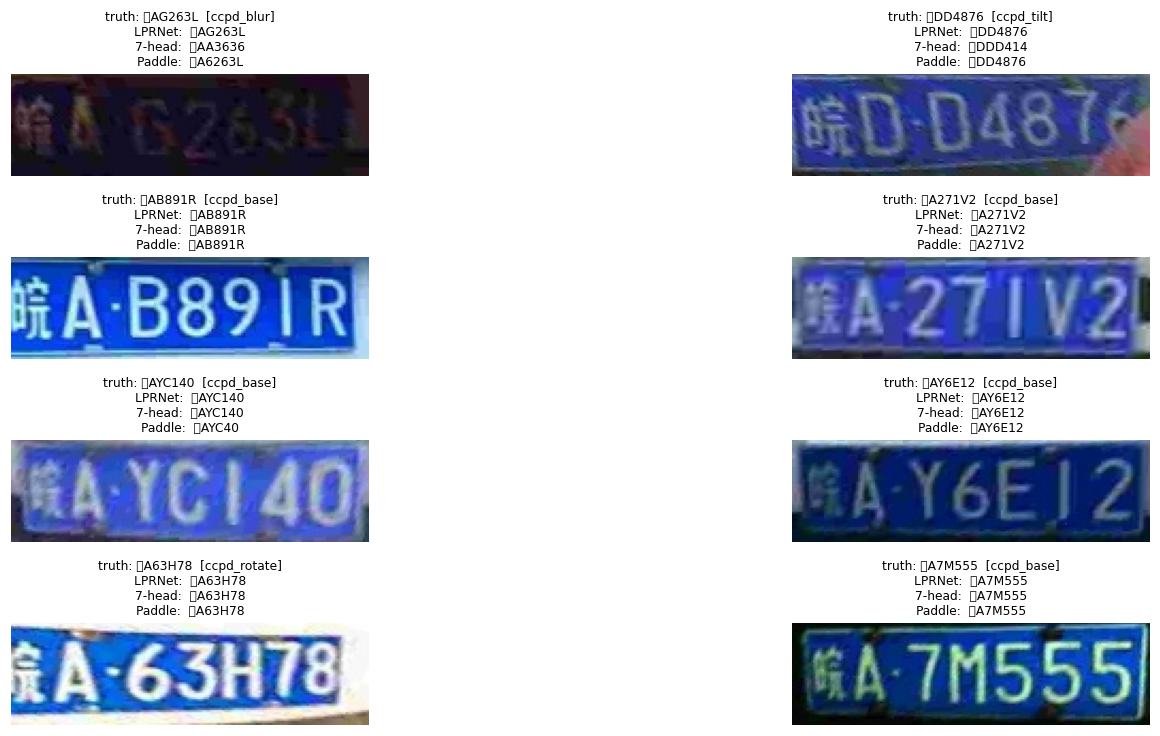

In [36]:
sample = test_df.sample(min(8, len(test_df)), random_state=0).reset_index(drop=True)
test_df_reset = test_df.reset_index(drop=True)
path_to_pos = {p: i for i, p in enumerate(test_df_reset["path"])}
sample["test_pos"] = sample["path"].map(path_to_pos)

def get_pred(i, preds_list):
    if preds_list is None or i is None or i >= len(preds_list): return "—"
    return preds_list[i][1]

cols, rows_n = 2, math.ceil(len(sample)/2)
fig, axes = plt.subplots(rows_n, cols, figsize=(cols*8, rows_n*1.7))
axes = np.array(axes).reshape(-1)
for ax, (_, r) in zip(axes, sample.iterrows()):
    img = cv2.imread(r["path"])
    if img is None: ax.axis("off"); continue
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    pos = int(r["test_pos"]) if not pd.isna(r["test_pos"]) else None
    title = (f"truth: {r['plate']}  [{r['subset']}]\n"
             f"LPRNet:  {get_pred(pos, lprnet_test_preds)}\n"
             f"7-head:  {get_pred(pos, head7_test_preds)}\n"
             f"Paddle:  {get_pred(pos, paddle_test_preds)}")
    ax.set_title(title, fontsize=8); ax.axis("off")
for ax in axes[len(sample):]: ax.axis("off")
plt.tight_layout(); plt.show()